**[🏠 Course Home](00_START_HERE.ipynb) | ⏮️ Previous: [Sheet 5: Production Scale — Multi-Chain MCMC & Diagnostics](05_mcmc_production_diagnostics.ipynb) | ⏭️ Next: [Sheet 7: Actionable Systems — Bayesian Decision Theory & Predictive Checks](07_bayesian_decision_theory_and_predictive_checks.ipynb)**

---

# Sheet 6: Dynamic Filtering — Calibrating Memory Decay (γ) for Streaming Systems
### *Solving Asymptotic Blindness and Non-Stationary Drift with Exponential Fading Memory*

In Sheets 1 through 5, we assumed the true parameter $\theta$ is static across all observations. In real-world engineering and production environments, however, systems are **non-stationary**: bug fixes deploy, infrastructure drifts, and failure rates shift overnight.

Under standard Bayes, accumulating thousands of historical runs causes **Asymptotic Blindness (Bayesian Rigidity)**. In this sheet, we derive and calibrate **Dynamic State-Space Filtering with Exponential Memory Decay** (Cauchy functional equation, Poisson hazard rate, West-Harrison filtering), compare it head-to-head against rolling windows, and optimize discount factor $\gamma$ using pre-quential backtesting.

---

### The Non-Stationary Challenge & The Calibration Playbook

In **Sheet 1**, we mastered online conjugate updating for automated tests. But when tests or infrastructure change over time, static Bayesian accumulation causes the posterior to freeze—ignoring fresh incoming failures. We resolve this by introducing **exponential memory decay**:
$$\alpha_t = \gamma \, \alpha_{t-1} + k_t, \qquad \beta_t = \gamma \, \beta_{t-1} + (n_t - k_t)$$

This masterclass answers the two deepest engineering and mathematical questions in dynamic Bayesian modeling:
1. **The Mathematical Foundations**: Why is exponential decay the *only* mathematically coherent choice (Cauchy's functional equation, Poisson environmental shocks, West-Harrison state space)? Why do rolling windows and linear decay fail?
2. **The Calibration Playbook**: How do you pick $\gamma$? We explore **four complementary calibration methods** ranging from analytical half-lives to automated pre-quential log-likelihood backtesting.

---

### Table of Contents
1. **Part 1: The Non-Stationary Dilemma & The Rigidity Trap**
2. **Part 2: The Mathematical Justification for Exponential Memory Decay**
3. **Part 3: Head-to-Head Comparison: Exponential vs. Rolling Window vs. Static Bayes**
4. **Part 4: Architectural Matrix (Exponential vs. Rolling vs. Linear vs. Harmonic)**
5. **Part 5: Calibration Method 1 — The Half-Life Rule ($t_{1/2}$)**
6. **Part 6: Calibration Method 2 — Steady-State Effective Sample Size ($N_{\text{eff}}$)**
7. **Part 7: Calibration Method 3 — Responsiveness vs. False Alarm Trade-Off**
8. **Part 8: Calibration Method 4 — Empirical Backtesting & Score Optimization**
9. **Part 9: Advanced Architecture — Event-Triggered & Adaptive Decay**
10. **Part 10: Production Cheat Sheet & Hands-On Challenge Exercises**


## Part 1: The Non-Stationary Dilemma & The Rigidity Trap

Standard Bayesian inference assumes the data-generating process is **stationary** (the true parameter $\theta$ never changes). 

In production software and continuous telemetry, this assumption is false. Code commits break tests, PRs fix regressions, and infrastructure shifts.

### The Asymptotic Blindness Formula
Under static Bayes, cumulative sample size grows as $N_t = N_0 + n \cdot t$. The posterior variance shrinks as $O(1/N_t) \to 0$. 
If a test passes $10,000$ times over 6 months and a commit breaks it today, even after **50 consecutive failures**, the static Bayesian posterior is:
$$\mathbb{E}[\theta] = \frac{1 + 50}{10,000 + 50} \approx 0.5\%$$
The model is **completely paralyzed by ancient history**. We must decay the past.

## Part 2: The Mathematical Justification for Exponential Memory Decay

Why must memory decay be **exponential** rather than linear or a rolling 14-day window? There are **four converging mathematical reasons**:

### 1. Cauchy's Functional Equation & $O(1)$ Streaming
In streaming microservices, we cannot store the entire history of millions of individual runs. To update today's state from yesterday's summary state in **$O(1)$ constant time and $O(1)$ space**, the memory weighting function $w(t)$ must satisfy the **homomorphism property**:
$$w(t_1 + t_2) = w(t_1) \cdot w(t_2)$$
Cauchy (1821) proved that the **only** continuous, non-zero functions satisfying this are exponentials:
$$w(t) = e^{-\lambda t} = \gamma^t$$
Any other decay function (e.g. rolling window, linear) mathematically requires storing the entire raw event log in memory.

### 2. Constant Hazard Rate of Environmental Shocks (Poisson Process)
Code commits, dependency bumps, and environment disruptions arrive according to a Poisson process with constant hazard rate $\lambda$. The survival probability of zero disruptions over interval $\Delta t$ is strictly exponential:
$$P(\text{system unchanged over } \Delta t) = e^{-\lambda \Delta t} = \gamma^{\Delta t}$$
By the Law of Total Probability, older evidence must be discounted by the probability that the underlying process has remained unchanged.

### 3. West & Harrison Dynamic Conjugate Filtering (Kalman Equivalence)
West & Harrison (1997) proved that discounting Fisher information by $\gamma \in (0, 1)$ injects stochastic variance into the state while **keeping the posterior in exact closed-form Beta distributions**, avoiding the computational cost of particle filters.

### 4. Bounded Information Horizon (Geometric Series)
Because $\sum_{j=0}^\infty \gamma^j = \frac{1}{1 - \gamma}$, effective sample size converges to a stable stationary ceiling: $N_{\text{eff}} = \frac{N}{1 - \gamma}$.

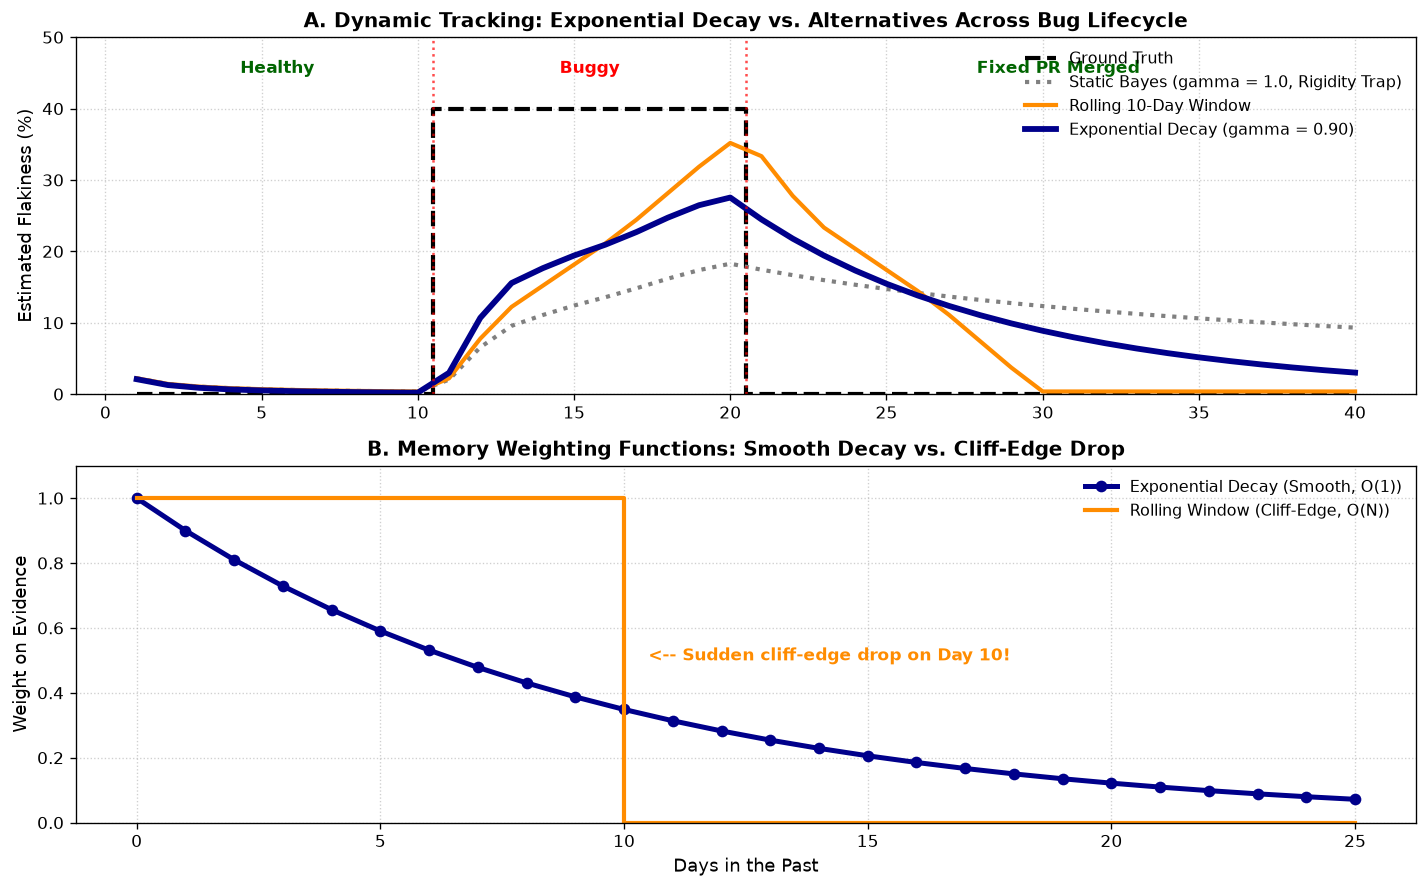

In [1]:
# Simulation: Exponential Decay vs. Rolling Window vs. Static Bayes
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
days = 40
runs_per_day = 25

# 40-Day Lifecycle: Healthy (0%) -> Buggy (40%) -> Fixed (0%)
true_theta = np.array([0.00]*10 + [0.40]*10 + [0.00]*20)
daily_fails = np.random.binomial(runs_per_day, true_theta)

# 1. Static Bayes (No Decay, gamma = 1.0)
static_mean = np.zeros(days)
a_s, b_s = 1.0, 19.0
for d in range(days):
    a_s += daily_fails[d]; b_s += (runs_per_day - daily_fails[d])
    static_mean[d] = a_s / (a_s + b_s)

# 2. Exponential Decay (gamma = 0.90, half-life ~ 6.6 days)
gamma = 0.90
exp_mean = np.zeros(days)
a_e, b_e = 1.0, 19.0
for d in range(days):
    a_e = gamma * a_e + daily_fails[d]; b_e = gamma * b_e + (runs_per_day - daily_fails[d])
    exp_mean[d] = a_e / (a_e + b_e)

# 3. Rolling 10-Day Window (Unweighted memory)
roll_mean = np.zeros(days)
for d in range(days):
    start_d = max(0, d - 9)
    roll_mean[d] = (1.0 + np.sum(daily_fails[start_d:d+1])) / (20.0 + (d - start_d + 1) * runs_per_day)

# 2-Panel Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7.5), dpi=120)
days_axis = np.arange(1, days + 1)

# Panel 1: Response across Lifecycle
ax1.step(days_axis, true_theta * 100, where='mid', color='black', linestyle='--', linewidth=2.5, label='Ground Truth')
ax1.plot(days_axis, static_mean * 100, color='gray', linestyle=':', linewidth=2.5, label='Static Bayes (gamma = 1.0, Rigidity Trap)')
ax1.plot(days_axis, roll_mean * 100, color='darkorange', linewidth=2.5, label='Rolling 10-Day Window')
ax1.plot(days_axis, exp_mean * 100, color='darkblue', linewidth=3.5, label='Exponential Decay (gamma = 0.90)')

ax1.axvline(10.5, color='red', linestyle=':', alpha=0.7)
ax1.axvline(20.5, color='red', linestyle=':', alpha=0.7)
ax1.text(5.5, 45, "Healthy", ha='center', color='darkgreen', fontweight='bold')
ax1.text(15.5, 45, "Buggy", ha='center', color='red', fontweight='bold')
ax1.text(30.5, 45, "Fixed PR Merged", ha='center', color='darkgreen', fontweight='bold')

ax1.set_title("A. Dynamic Tracking: Exponential Decay vs. Alternatives Across Bug Lifecycle", fontsize=12, fontweight='bold')
ax1.set_ylabel("Estimated Flakiness (%)", fontsize=11)
ax1.set_ylim(0, 50)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper right', frameon=False, fontsize=9.5)

# Panel 2: Memory Weight Functions
t_lags = np.arange(26)
w_exp = gamma**t_lags
w_roll = np.where(t_lags < 10, 1.0, 0.0)

ax2.plot(t_lags, w_exp, color='darkblue', marker='o', linewidth=3, label='Exponential Decay (Smooth, O(1))')
ax2.step(t_lags, w_roll, where='post', color='darkorange', linewidth=2.5, label='Rolling Window (Cliff-Edge, O(N))')
ax2.text(10.5, 0.5, "<-- Sudden cliff-edge drop on Day 10!", color='darkorange', fontweight='bold')

ax2.set_title("B. Memory Weighting Functions: Smooth Decay vs. Cliff-Edge Drop", fontsize=12, fontweight='bold')
ax2.set_xlabel("Days in the Past", fontsize=11)
ax2.set_ylabel("Weight on Evidence", fontsize=11)
ax2.set_ylim(0, 1.1)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper right', frameon=False, fontsize=9.5)

plt.tight_layout()
plt.show()


## Part 4: Architectural Matrix of Memory Models

| Fading Memory Model | Formula $w(t)$ | Complexity | Memory Required | Mathematical Flaws & Failure Modes |
| :--- | :--- | :---: | :---: | :--- |
| **Exponential Decay** | **$\gamma^t = e^{-\lambda t}$** | **$O(1)$** | **2 floats ($\alpha, \beta$)** | **None.** Smooth, memoryless, matches Poisson shocks, strictly conjugate. |
| **Static Bayes (No Decay)** | $w(t) = 1$ | $O(1)$ | 2 floats | **Bayesian Rigidity Trap**: Paralyzed by ancient history as $N \to \infty$. |
| **Rolling Rectangular Window** | $\mathbf{1}_{\{t \le W\}}$ | $O(N)$ | Full event array | **Cliff-Edge Artifacts**: Test score jumps abruptly when old runs drop off. |
| **Linear Decay** | $\max(0, 1 - c \cdot t)$ | $O(N)$ | Full event array | Reaches zero/negative weights, violating probability axioms. |
| **Harmonic Decay** | $1 / t$ | $O(N)$ | Full event array | Harmonic series diverges ($\sum 1/t = \infty$), failing to prevent rigidity. |

## Part 5: Calibration Method 1 — The Half-Life Rule ($t_{1/2}$)

The **memory half-life** $t_{1/2}$ is the elapsed time until an observation retains exactly $50\%$ of its initial weight:
$$\gamma^{t_{1/2}} = 0.5 \implies t_{1/2} = \frac{\ln(0.5)}{\ln(\gamma)}$$

Conversely, if your team works in 2-week sprints (14 days) and wants evidence from the previous sprint to retain $25\%$ weight, set $\gamma = 0.25^{1/14} \approx 0.906$.

=== Memory Half-Life for Different Gamma Values ===
Gamma = 0.80  -->  Daily Decay: 20.0%  -->  Half-Life:   3.1 days
Gamma = 0.88  -->  Daily Decay: 12.0%  -->  Half-Life:   5.4 days
Gamma = 0.92  -->  Daily Decay:  8.0%  -->  Half-Life:   8.3 days
Gamma = 0.95  -->  Daily Decay:  5.0%  -->  Half-Life:  13.5 days
Gamma = 0.98  -->  Daily Decay:  2.0%  -->  Half-Life:  34.3 days


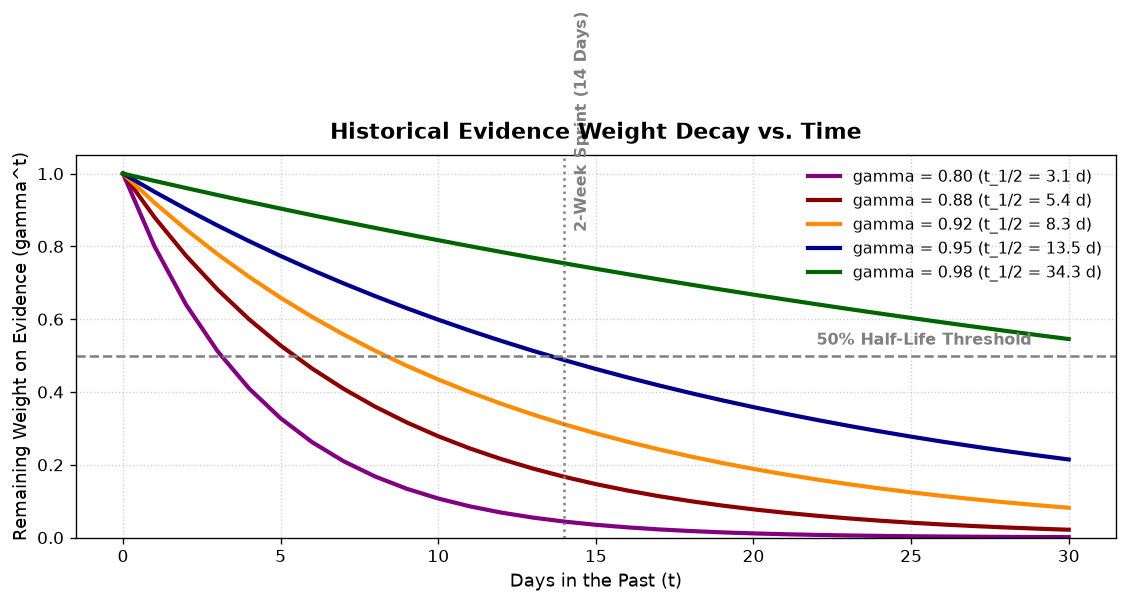

In [2]:
# Calibration Method 1: Half-Life Analysis
import numpy as np
import matplotlib.pyplot as plt

gammas = np.array([0.80, 0.88, 0.92, 0.95, 0.98])
half_lives = np.log(0.5) / np.log(gammas)

print("=== Memory Half-Life for Different Gamma Values ===")
for g, hl in zip(gammas, half_lives):
    print(f"Gamma = {g:.2f}  -->  Daily Decay: {100 * (1 - g):4.1f}%  -->  Half-Life: {hl:5.1f} days")

# Plot Exponential Weight Decay Curves Over 30 Days
days_vec = np.arange(31)
colors = ["purple", "darkred", "darkorange", "darkblue", "darkgreen"]

plt.figure(figsize=(9.5, 5), dpi=120)
for i, g in enumerate(gammas):
    plt.plot(days_vec, g**days_vec, color=colors[i], linewidth=2.5, label=f"gamma = {g:.2f} (t_1/2 = {half_lives[i]:.1f} d)")

plt.axhline(0.5, color='gray', linestyle='--', linewidth=1.5)
plt.text(22, 0.53, "50% Half-Life Threshold", color='gray', fontsize=9.5, fontweight='bold')
plt.axvline(14, color='gray', linestyle=':', linewidth=1.5)
plt.text(14.3, 0.85, "2-Week Sprint (14 Days)", color='gray', rotation=90, fontsize=9.5, fontweight='bold')

plt.title("Historical Evidence Weight Decay vs. Time", fontsize=13, fontweight='bold', pad=10)
plt.xlabel("Days in the Past (t)", fontsize=11)
plt.ylabel("Remaining Weight on Evidence (gamma^t)", fontsize=11)
plt.ylim(0, 1.05)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', frameon=False, fontsize=9.5)
plt.tight_layout()
plt.show()


## Part 6: Calibration Method 2 — Steady-State Effective Sample Size ($N_{\text{eff}}$)

Under continuous operation with $N$ runs per day, the total accumulated pseudo-counts form a geometric progression converging to:
$$N_{\text{eff}} = \lim_{T \to \infty} \sum_{t=0}^{T-1} N \, \gamma^t = \frac{N}{1 - \gamma}$$

This gives the **information horizon** of the filter: $\gamma = 0.92$ at 20 runs/day equals having a permanent memory of exactly 250 test runs.

=== Asymptotic Effective Sample Size Ceiling (N = 20 runs/day) ===
Gamma = 0.80  -->  Max Information Horizon:  100 equivalent test runs
Gamma = 0.88  -->  Max Information Horizon:  167 equivalent test runs
Gamma = 0.92  -->  Max Information Horizon:  250 equivalent test runs
Gamma = 0.95  -->  Max Information Horizon:  400 equivalent test runs
Gamma = 0.98  -->  Max Information Horizon: 1000 equivalent test runs


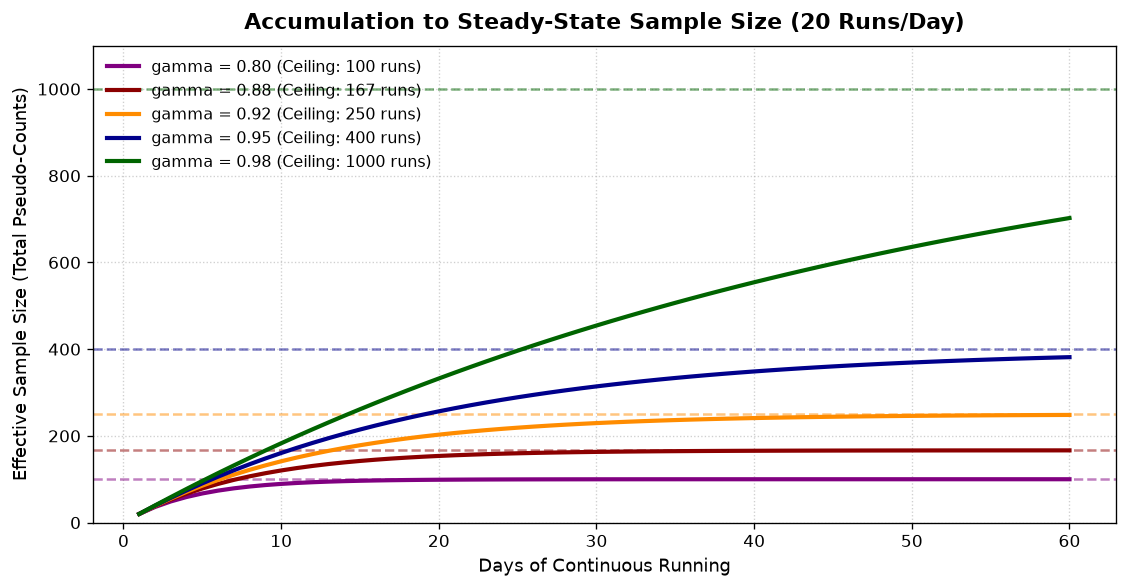

In [3]:
# Calibration Method 2: Effective Sample Size Accumulation
import numpy as np
import matplotlib.pyplot as plt

N_daily = 20
days_vec = np.arange(1, 61)
N_eff_ceilings = N_daily / (1 - gammas)

print("=== Asymptotic Effective Sample Size Ceiling (N = 20 runs/day) ===")
for g, ceil in zip(gammas, N_eff_ceilings):
    print(f"Gamma = {g:.2f}  -->  Max Information Horizon: {ceil:4.0f} equivalent test runs")

plt.figure(figsize=(9.5, 5), dpi=120)
for i, g in enumerate(gammas):
    s_t = N_daily * (1 - g**days_vec) / (1 - g)
    plt.plot(days_vec, s_t, color=colors[i], linewidth=2.5, label=f"gamma = {g:.2f} (Ceiling: {int(round(N_eff_ceilings[i]))} runs)")
    plt.axhline(N_eff_ceilings[i], color=colors[i], linestyle='--', alpha=0.5)

plt.title("Accumulation to Steady-State Sample Size (20 Runs/Day)", fontsize=13, fontweight='bold', pad=10)
plt.xlabel("Days of Continuous Running", fontsize=11)
plt.ylabel("Effective Sample Size (Total Pseudo-Counts)", fontsize=11)
plt.ylim(0, 1100)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', frameon=False, fontsize=9.5)
plt.tight_layout()
plt.show()


## Part 7: Calibration Method 3 — Responsiveness vs. False Alarm Trade-Off

Lower $\gamma$ reacts faster to newly introduced bugs, but increases false alarm rates during healthy periods.
We simulate a 30-day lifecycle:
- **Days 1-10**: 1% healthy
- **Days 11-14**: 25% flaky bug
- **Days 15-30**: Bug fixed (0%)

We measure the **Quarantine Recovery Time**: how many days after the fix does the $95\%$ upper bound drop back below $5\%$?

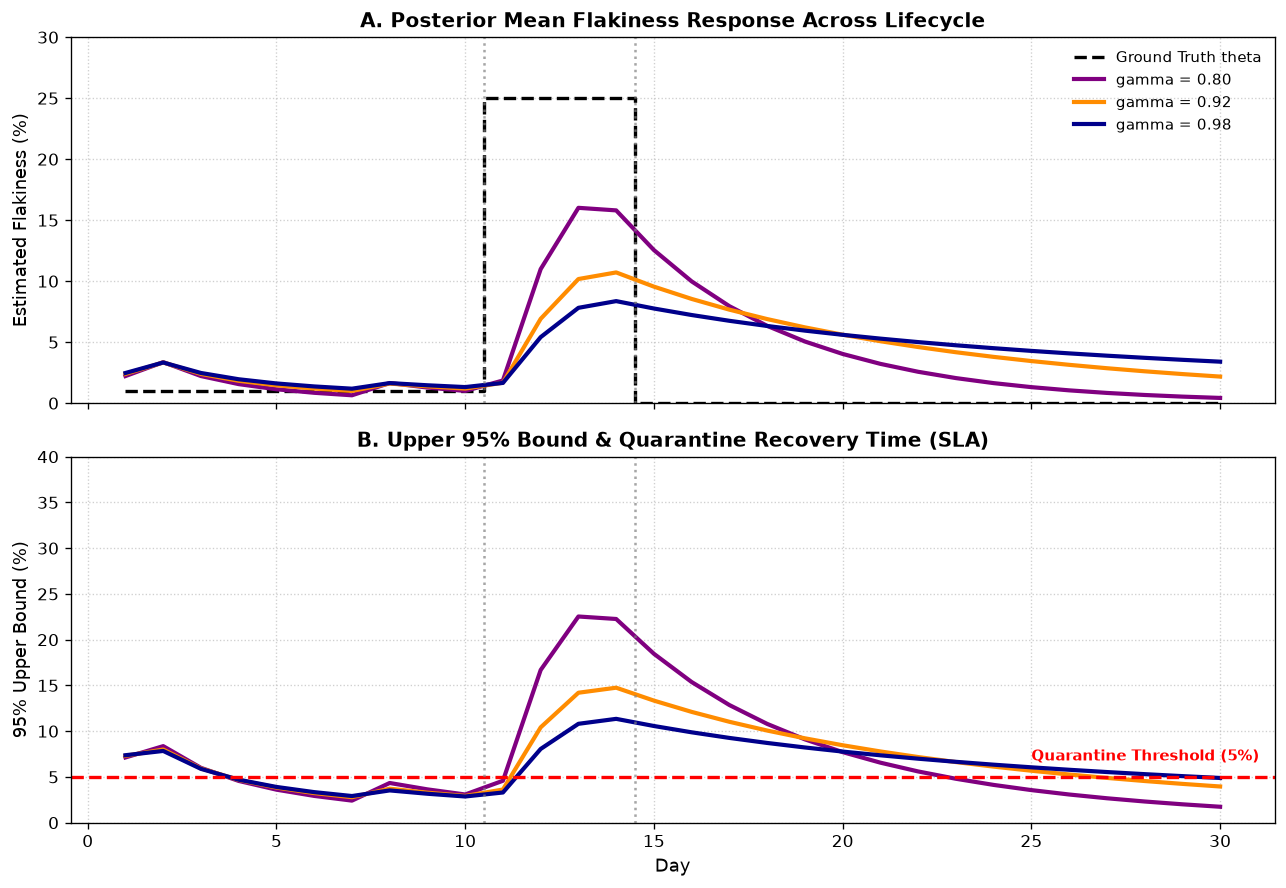

=== Quarantine Recovery Days (Post-Fix on Day 14) ===
Gamma = 0.80  -->  De-quarantined on Day 23 (9 days after bug fix)
Gamma = 0.92  -->  De-quarantined on Day 27 (13 days after bug fix)
Gamma = 0.98  -->  De-quarantined on Day 30 (16 days after bug fix)


In [4]:
# Calibration Method 3: Lifecycle Simulation
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

np.random.seed(42)
days_total = 30
runs_per_day = 20
true_theta_sim = np.array([0.01]*10 + [0.25]*4 + [0.00]*16)
daily_failures = np.random.binomial(runs_per_day, true_theta_sim)

test_gammas = [0.80, 0.92, 0.98]
sim_colors = ["purple", "darkorange", "darkblue"]

results_mean = np.zeros((days_total, len(test_gammas)))
results_q95 = np.zeros((days_total, len(test_gammas)))

for g_idx, g in enumerate(test_gammas):
    a, b = 1.0, 19.0
    for d in range(days_total):
        a = g * a + daily_failures[d]
        b = g * b + (runs_per_day - daily_failures[d])
        results_mean[d, g_idx] = 100 * (a / (a + b))
        results_q95[d, g_idx] = 100 * stats.beta.ppf(0.95, a, b)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7.5), dpi=120, sharex=True)
days_axis = np.arange(1, days_total + 1)

# Panel A: Posterior Mean
ax1.step(days_axis, 100 * true_theta_sim, where='mid', color='black', linestyle='--', linewidth=2, label='Ground Truth theta')
for g_idx, g in enumerate(test_gammas):
    ax1.plot(days_axis, results_mean[:, g_idx], color=sim_colors[g_idx], linewidth=2.5, label=f"gamma = {g:.2f}")

ax1.axvline(10.5, color='gray', linestyle=':', alpha=0.7)
ax1.axvline(14.5, color='gray', linestyle=':', alpha=0.7)
ax1.set_title("A. Posterior Mean Flakiness Response Across Lifecycle", fontsize=12, fontweight='bold')
ax1.set_ylabel("Estimated Flakiness (%)", fontsize=11)
ax1.set_ylim(0, 30)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper right', frameon=False, fontsize=9)

# Panel B: Upper 95% Bound
for g_idx, g in enumerate(test_gammas):
    ax2.plot(days_axis, results_q95[:, g_idx], color=sim_colors[g_idx], linewidth=2.5, label=f"gamma = {g:.2f}")

ax2.axhline(5.0, color='red', linestyle='--', linewidth=2, label='Quarantine Threshold (5%)')
ax2.text(25, 6.8, "Quarantine Threshold (5%)", color='red', fontsize=9, fontweight='bold')
ax2.axvline(10.5, color='gray', linestyle=':', alpha=0.7)
ax2.axvline(14.5, color='gray', linestyle=':', alpha=0.7)

ax2.set_title("B. Upper 95% Bound & Quarantine Recovery Time (SLA)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Day", fontsize=11)
ax2.set_ylabel("95% Upper Bound (%)", fontsize=11)
ax2.set_ylim(0, 40)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

print("=== Quarantine Recovery Days (Post-Fix on Day 14) ===")
for g_idx, g in enumerate(test_gammas):
    post_fix_q95 = results_q95[14:, g_idx]
    rec_indices = np.where(post_fix_q95 < 5.0)[0]
    if len(rec_indices) > 0:
        rec_day = rec_indices[0] + 1
        print(f"Gamma = {g:.2f}  -->  De-quarantined on Day {14 + rec_day} ({rec_day} days after bug fix)")
    else:
        print(f"Gamma = {g:.2f}  -->  STILL QUARANTINED after {days_total - 14} days!")


## Part 8: Calibration Method 4 — Empirical Backtesting & Score Optimization

In production machine learning, hyperparameters are chosen by **out-of-sample predictive performance**.
We use the **Pre-quential Log-Likelihood**: before updating state with day $t$'s data, compute the predictive probability of day $t$'s outcome under the Beta-Binomial distribution:

$$\ln P(k_t \mid n_t, \alpha_{t \mid t-1}, \beta_{t \mid t-1}) = \ln \binom{n_t}{k_t} + \ln \text{B}(\alpha + k_t, \beta + n_t - k_t) - \ln \text{B}(\alpha, \beta)$$

We evaluate candidate $\gamma \in [0.70, 0.99]$ to find the value that maximizes the cumulative one-step-ahead log-likelihood.

=== Backtesting Optimization Results ===
Optimal Gamma (Max Log-Likelihood) : 0.70 (Score: -40.45)
Optimal Gamma (Min Brier Score)    : 0.70 (Brier: 0.01031)


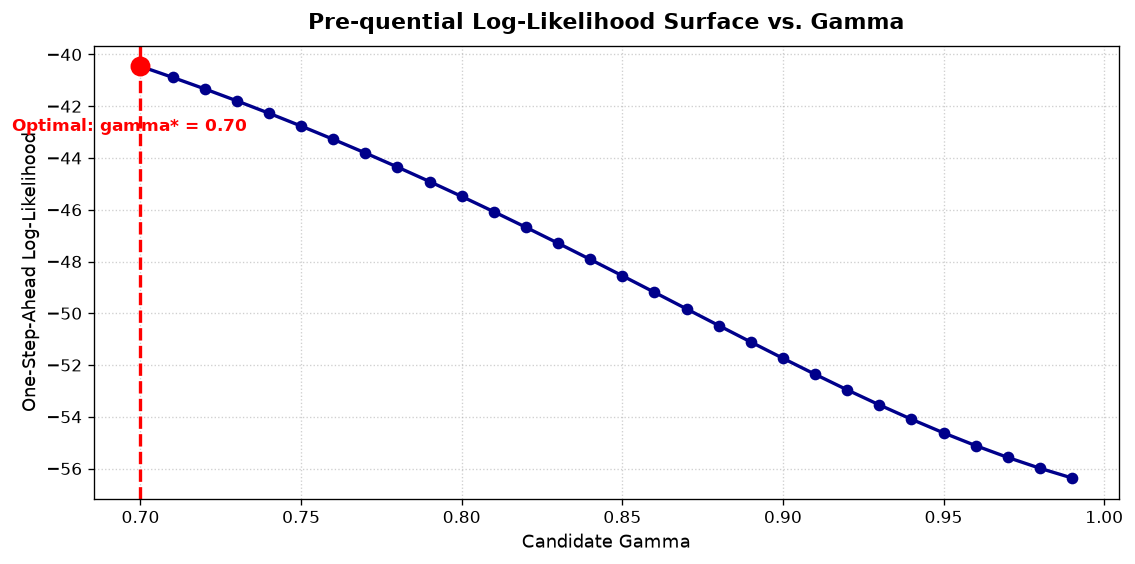

In [5]:
# Calibration Method 4: Backtesting Optimizer
import numpy as np
import scipy.special as sp
import matplotlib.pyplot as plt

def log_beta_binom(k, n, a, b):
    log_comb = sp.gammaln(n + 1) - sp.gammaln(k + 1) - sp.gammaln(n - k + 1)
    log_beta_num = sp.betaln(a + k, b + n - k)
    log_beta_den = sp.betaln(a, b)
    return log_comb + log_beta_num - log_beta_den

def evaluate_gamma(g, k_vec, n_vec, a0=1.0, b0=19.0):
    total_loglik = 0.0
    brier_sum = 0.0
    a, b = a0, b0
    for t in range(len(k_vec)):
        ll = log_beta_binom(k_vec[t], n_vec[t], a, b)
        pred_mean = a / (a + b)
        obs_rate = k_vec[t] / n_vec[t]
        total_loglik += ll
        brier_sum += (obs_rate - pred_mean)**2
        a = g * a + k_vec[t]
        b = g * b + (n_vec[t] - k_vec[t])
    return total_loglik, brier_sum / len(k_vec)

gamma_candidates = np.arange(0.70, 0.995, 0.01)
loglik_scores = np.zeros(len(gamma_candidates))
brier_scores = np.zeros(len(gamma_candidates))
n_vec = np.array([runs_per_day] * days_total)

for i, g in enumerate(gamma_candidates):
    ll, br = evaluate_gamma(g, daily_failures, n_vec)
    loglik_scores[i] = ll
    brier_scores[i] = br

best_idx = np.argmax(loglik_scores)
best_gamma = gamma_candidates[best_idx]

print("=== Backtesting Optimization Results ===")
print(f"Optimal Gamma (Max Log-Likelihood) : {best_gamma:.2f} (Score: {loglik_scores[best_idx]:.2f})")
print(f"Optimal Gamma (Min Brier Score)    : {gamma_candidates[np.argmin(brier_scores)]:.2f} (Brier: {np.min(brier_scores):.5f})")

plt.figure(figsize=(9.5, 4.8), dpi=120)
plt.plot(gamma_candidates, loglik_scores, color='darkblue', marker='o', linewidth=2)
plt.axvline(best_gamma, color='red', linestyle='--', linewidth=2)
plt.scatter(best_gamma, loglik_scores[best_idx], color='red', s=120, zorder=5)
plt.text(best_gamma - 0.04, loglik_scores[best_idx] - 2.5, f"Optimal: gamma* = {best_gamma:.2f}", color='red', fontweight='bold')

plt.title("Pre-quential Log-Likelihood Surface vs. Gamma", fontsize=13, fontweight='bold', pad=10)
plt.xlabel("Candidate Gamma", fontsize=11)
plt.ylabel("One-Step-Ahead Log-Likelihood", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


## Part 9: Advanced Architecture — Event-Triggered & Adaptive Decay

In modern enterprise pipelines, $\gamma$ does not have to be fixed permanently:
1. **Git Commit / Deployment Hooks**: Whenever a PR modifies a test's source file, trigger an instantaneous shock $\gamma_{\text{shock}} = 0.50$ (cutting old memory by half immediately).
2. **Surprise-Driven Adaptive Decay**: If observed daily failures deviate drastically from the prior predictive mean (high Mahalanobis distance), dynamically drop $\gamma$ to adapt quickly to regime shifts.
3. **Idle Decay**: If a test is not run for over a weekend (3 days of zero runs), apply $\gamma^3$ to reflect increased uncertainty over elapsed wall-clock time.

## Part 10: Production Cheat Sheet & Hands-On Exercises

### Rule-of-Thumb Decision Tree
- **Fast Sprint Cycle (1-2 weeks)**: Choose $\gamma = 0.88 - 0.92$ ($t_{1/2} \approx 5 - 8$ days).
- **Slow Enterprise Release (Monthly)**: Choose $\gamma = 0.95 - 0.97$ ($t_{1/2} \approx 14 - 23$ days).
- **High-Volume Continuous CI (>100 runs/day)**: Choose $\gamma = 0.95$, giving $N_{\text{eff}} = 2,000$ runs.

## 🎯 Check Your Understanding: 3-Tier Scaffolding Exercises

Sharpen your intuition and practice the mathematical concepts introduced in this sheet. Write your solutions in the interactive attempt cells below before expanding the verified solutions.

---

### 🟢 Tier 1 (Warm-Up): The Half-Life of Empirical Evidence
> **Scenario**: A CI/CD reliability pipeline updates a test flakiness tracker daily with decay factor $\gamma = 0.95$.
> 1. Calculate the evidence half-life $t_{1/2} = \frac{\ln(0.5)}{\ln(\gamma)}$ in days.
> 2. How much weight does an execution that occurred $30\text{ days ago}$ retain relative to today's execution ($k = 30$)?
> 3. If a bug was introduced 30 days ago and then fixed, will the historical flakiness still trigger alarms?

In [ ]:
# ============================================================
# 🟢 Tier 1: Your Turn — Attempt the Problem Here
# ============================================================
import numpy as np

gamma = 0.95

# 1. Compute evidence half-life in days:
# t_half = np.log(0.5) / np.log(gamma)

# 2. Compute remaining weight after 30 days:
# weight_30 = gamma ** 30

# print(f"Evidence Half-Life: {t_half:.2f} days")
# print(f"Remaining weight after 30 days: {weight_30:.2%}")


<details>
<summary><b>🔍 Click here to view the solution & derivation</b></summary>

**Answer**:
1. **Half-Life**:
   $$t_{1/2} = \frac{\ln(0.5)}{\ln(0.95)} = \frac{-0.69315}{-0.05129} \approx 13.5\text{ days}$$
2. **Remaining Weight**:
   $$w_{30} = \gamma^{30} = 0.95^{30} \approx 0.2146 = 21.46\%$$

```python
import numpy as np
gamma = 0.95
t_half = np.log(0.5) / np.log(gamma)
weight_30 = gamma ** 30
print(f'Half-life: {t_half:.1f} days, Weight after 30 days: {weight_30*100:.2f}%')
```

3. **Engineering Impact**: After 30 days (more than two half-lives), nearly **$80\%$ of the bug's historical evidence has evaporated**. As long as recent runs pass, the posterior failure rate will rapidly decay below the quarantine threshold, automatically unblocking the deployment pipeline without manual database resets.
</details>

---

### 🟡 Tier 2 (Guided Calculation): Steady-State Effective Sample Size ($N_{\text{eff}}$)
> **Scenario**: A payment gateway executes $n = 50$ health check transactions per batch. 
> The engineering team sets the discount factor to $\gamma = 0.90$.
> 1. Compute the steady-state effective sample size $N_{\text{eff}} = \frac{n}{1 - \gamma}$.
> 2. What would the effective sample size be if they tightened memory to $\gamma = 0.98$?
> 3. What is the fundamental engineering trade-off between $\gamma = 0.90$ and $\gamma = 0.98$?

In [ ]:
# ============================================================
# 🟡 Tier 2: Your Turn — Attempt the Problem Here
# ============================================================
n = 50  # tests per batch

# 1. Steady-state sample size under gamma = 0.90:
gamma_1 = 0.90
# n_eff_1 = n / (1 - gamma_1)

# 2. Steady-state sample size under gamma = 0.98:
gamma_2 = 0.98
# n_eff_2 = n / (1 - gamma_2)

# print(f"N_eff (gamma = 0.90): {n_eff_1:.1f} tests")
# print(f"N_eff (gamma = 0.98): {n_eff_2:.1f} tests")


<details>
<summary><b>🔍 Click here to view the solution & code</b></summary>

**Answer**:
1. For $\gamma = 0.90$:
   $$N_{\text{eff}} = \frac{50}{1 - 0.90} = \frac{50}{0.10} = 500\text{ runs}$$
2. For $\gamma = 0.98$:
   $$N_{\text{eff}} = \frac{50}{1 - 0.98} = \frac{50}{0.02} = 2,500\text{ runs}$$

```python
n = 50
n_eff_90 = n / (1.0 - 0.90)  # 50 / 0.10 = 500
n_eff_98 = n / (1.0 - 0.98)  # 50 / 0.02 = 2500
print(f'N_eff (gamma=0.90): {n_eff_90:.0f}, N_eff (gamma=0.98): {n_eff_98:.0f}')
```

3. **Engineering Trade-off (Responsiveness vs. Variance)**:
   - $\gamma = 0.90$ ($N_{\text{eff}} = 500$): Extremely responsive to sudden degradations. Adapts within hours, but wider posterior credible intervals during quiet periods.
   - $\gamma = 0.98$ ($N_{\text{eff}} = 2,500$): Razor-thin credible intervals during steady-state, but sluggish to detect sudden outages because it takes thousands of observations to overcome historical inertia.
</details>

---

### 🔴 Tier 3 (Production Challenge): The Rolling Window Cliff-Edge Artifact
> **Scenario**: An SRE team monitors microservice error rates using a 30-day sliding rectangular window. 
> Exactly 31 days ago, a major database outage caused 500 requests to fail. 
> At midnight last night, day 31 fell off the back of the sliding window. 
> The dashboard suddenly showed a massive drop in estimated failure rate, and the on-call engineer received an automated alert: *"Anomaly: Sudden 80% improvement in error rate."*
> 1. Why does a rectangular sliding window produce this artificial "ghost signal"?
> 2. How does the exponential discount filter $\text{Beta}(\gamma \alpha_t, \gamma \beta_t)$ mathematically eliminate cliff-edge artifacts?

In [ ]:
# ============================================================
# 🔴 Tier 3: Your Turn — Attempt the Problem Here
# ============================================================
# Contrast:
# 1. 30-day rectangular sliding window: drops day t-30 with weight 1.0 -> 0.0 (cliff-edge)
# 2. Exponential discount filter (gamma): smooth weight gamma^k, no cliff edge

# Write your explanation and analysis below:


<details>
<summary><b>🔍 Click here to view the architectural comparison</b></summary>

**Architectural Comparison**:
1. **The Cliff-Edge Pathology of Rectangular Windows**:
   A sliding window assigns a step-function weight to evidence:
   $$w(k) = \begin{cases} 1.0 & \text{if } k \le 30 \text{ days} \\ 0.0 & \text{if } k > 30 \text{ days} \end{cases}$$
   When an extreme event (e.g., 500 failures) reaches age $k = 31$, its weight abruptly collapses from $1.0$ to $0.0$ in a single timestep. This produces a **phantom discontinuity** in the metric that has nothing to do with current system performance.
2. **Exponential Smoothing Guarantee**:
   The Bayesian exponential decay assigns smooth geometric weighting:
   $$w(k) = \gamma^k$$
   Because $\gamma^k - \gamma^{k+1} = \gamma^k(1 - \gamma)$ is continuous and infinitesimal for each step, past events fade smoothly toward zero:
   - There is no cliff-edge, no arbitrary cutoff date, and no ghost signals.
</details>

---
**[🏠 Course Home](00_START_HERE.ipynb) | ⏮️ Previous: [Sheet 5: Production Scale — Multi-Chain MCMC & Diagnostics](05_mcmc_production_diagnostics.ipynb) | ⏭️ Next: [Sheet 7: Actionable Systems — Bayesian Decision Theory & Predictive Checks](07_bayesian_decision_theory_and_predictive_checks.ipynb)**